# Part B Q4 — GRPO Training with Full Composite Reward

**Goal**: Fine-tune the **base model** `meta-llama/Llama-3.2-3B-Instruct` using GRPO with a composite reward:
- **Correctness Reward** (weight 0.4): Cosine similarity vs. ground truth answer (sentence-transformers)
- **Format Reward** (weight 0.2): Strict alphanumeric/punctuation regex + sentence capitalisation
- **Style Reward** (weight 0.4): DistilBERT Yoda-style classifier score

**Key constraints**: T4 15 GB GPU → QLoRA (4-bit + LoRA), `num_generations=4`, `per_device_train_batch_size=4`.

**Dataset**: `Datasets_3b_processed/yoda_{train,val,test}.csv` (500/200/500 rows from Natural Questions)

## Cell 0 — Install Dependencies

In [1]:
# Install required packages
# Run this cell first; runtime will restart automatically after installation.
!pip install -q trl>=0.12.0 peft transformers bitsandbytes accelerate datasets sentence-transformers evaluate
print('Installation complete.')

Installation complete.


## Cell 1 — Imports & Global CONFIG

In [2]:
# ============================================================
#  CONFIGURATION — all tuneable parameters in one place
# ============================================================
MODEL_ID        = "meta-llama/Llama-3.2-3B-Instruct"  # base model (needs HF Token)

# Reward weights — adjust if one component does not converge
W_CORRECT       = 0.4   # increase if correctness reward stays flat
W_FORMAT        = 0.2   # usually stable; lower if it dominates
W_STYLE         = 0.4   # increase if style score stays low

# GRPO hyper-parameters
NUM_GENERATIONS = 4     # reduce to 2 if OOM (per_device_batch will also halve)
LEARNING_RATE   = 5e-6
NUM_EPOCHS      = 1     # 1 epoch ≈ 1–2 h on T4
GRAD_ACCUM      = 8     # effective batch = NUM_GENERATIONS * (GRAD_ACCUM // NUM_GENERATIONS)
MAX_NEW_TOKENS  = 128   # max tokens for generated response
MAX_PROMPT_LEN  = 256   # max tokens for prompt
LOGGING_STEPS   = 10
# NOTE: per_device_train_batch_size is set to NUM_GENERATIONS in GRPOConfig
#       (TRL 0.29 requires batch_size % num_generations == 0)

# LoRA config
LORA_R          = 16
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.05

# Classifier training (aligned with Part B Q1)
CLASSIFIER_EPOCHS   = 2.5  # Q1 uses 2.5 (3 epochs overfit)
CLASSIFIER_LR       = 2e-5
CLASSIFIER_BATCH    = 16   # Q1 uses 16

# Google Drive
SAVE_TO_DRIVE        = True   # save checkpoints/plots to Drive
DRIVE_CLASSIFIER_DIR = "/content/drive/MyDrive/CW1_PartB_Q4/yoda_classifier"
DRIVE_ADAPTER_DIR    = "/content/drive/MyDrive/CW1_PartB_Q4/grpo_adapter"

# Data paths
TRAIN_CSV = "/content/drive/MyDrive/CW1_PartB_Q4/Datasets_3b_processed/yoda_train.csv"
VAL_CSV   = "/content/drive/MyDrive/CW1_PartB_Q4/Datasets_3b_processed/yoda_val.csv"
TEST_CSV  = "/content/drive/MyDrive/CW1_PartB_Q4/Datasets_3b_processed/yoda_test.csv"

LOCAL_CLASSIFIER_DIR = "./yoda_classifier"
LOCAL_ADAPTER_DIR    = "./grpo_adapter"

# ── Training toggles ─────────────────────────────────────────
RUN_CLASSIFIER_TRAINING = True   # False = skip training, load existing weights from Drive/local
RUN_GRPO_TRAINING       = True   # False = skip GRPO training, load existing adapter from Drive/local
RUN_BEFORE_EXAMPLES     = True   # False = skip before-RLVR example generation
RUN_AFTER_EXAMPLES      = True   # False = skip after-RLVR example generation
# ─────────────────────────────────────────────────────────────

SEED = 42
# ============================================================

import os, re, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from typing import List, Dict, Any
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    TrainerCallback,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
from trl import GRPOTrainer, GRPOConfig
from sentence_transformers import SentenceTransformer

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {total_mem:.1f} GB")
else:
    print("WARNING: No GPU detected — training will be extremely slow.")
print(f"PyTorch: {torch.__version__}")
print(f"\n── Training toggle status ──")
print(f"  RUN_CLASSIFIER_TRAINING = {RUN_CLASSIFIER_TRAINING}")
print(f"  RUN_GRPO_TRAINING       = {RUN_GRPO_TRAINING}")
print(f"  RUN_BEFORE_EXAMPLES     = {RUN_BEFORE_EXAMPLES}")
print(f"  RUN_AFTER_EXAMPLES      = {RUN_AFTER_EXAMPLES}")

GPU: Tesla T4
VRAM: 14.6 GB
PyTorch: 2.10.0+cu128

── Training toggle status ──
  RUN_CLASSIFIER_TRAINING = True
  RUN_GRPO_TRAINING       = True
  RUN_BEFORE_EXAMPLES     = True
  RUN_AFTER_EXAMPLES      = True


## Cell 1b — HF Token & Google Drive Mount

In [3]:
# Mount Google Drive (needed to upload dataset and save checkpoints)
from google.colab import drive, userdata
drive.mount('/content/drive')

# HF Token — set via Colab Secrets: Settings → Secrets → Add "HF_TOKEN"
HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN
print("HF_TOKEN loaded:", HF_TOKEN[:8] + "..." if HF_TOKEN else "NOT FOUND — please set it in Secrets")

Mounted at /content/drive
HF_TOKEN loaded: HF_TOKEN_REDACTED...


## Cell 2 — Load Dataset

> **Before running**: Upload the `Datasets_3b_processed/` folder to `/content/` (or copy from Drive).

In [4]:
# Load data from Drive (paths configured in CONFIG above).
# Paths point directly to Drive — no need to copy files.
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train : {len(train_df):,} rows")
print(f"Val   : {len(val_df):,} rows")
print(f"Test  : {len(test_df):,} rows")
print("\nColumns:", list(train_df.columns))
print("\nSample row:")
display(train_df.head(2))

Train : 500 rows
Val   : 200 rows
Test  : 500 rows

Columns: ['id', 'question', 'answer_original', 'answer_yoda']

Sample row:


,id,question,answer_original,answer_yoda
0,train_44102,how many bees does a queen bee produce,"Queen bee Although the name might imply it, a ...","A queen bee, does not directly control the hiv..."
1,train_60126,what disney movie has the song a whole new world,Alan Menken Menken and Ashman's Beauty and the...,Menken and Ashman's Beauty and the Beast garne...


## Cell 3 — Train Yoda Style Classifier (Part B Q1)

We train a DistilBERT binary classifier: **label 1 = Yoda-style**, **label 0 = plain English**.  
Training data is constructed from `answer_yoda` (positive) and `answer_original` (negative).  
Training takes ~1 minute on T4.

In [5]:
# ── Check whether a pre-trained classifier already exists ─────────────────────
CLASSIFIER_AVAILABLE = False
if not RUN_CLASSIFIER_TRAINING:
    # Toggle is off: force-load from existing weights
    if SAVE_TO_DRIVE and os.path.isdir(DRIVE_CLASSIFIER_DIR):
        print(f"[Training skipped] Loading classifier from Drive: {DRIVE_CLASSIFIER_DIR}")
        CLASSIFIER_AVAILABLE = True
    elif os.path.isdir(LOCAL_CLASSIFIER_DIR):
        print(f"[Training skipped] Loading classifier from local: {LOCAL_CLASSIFIER_DIR}")
        CLASSIFIER_AVAILABLE = True
    else:
        print("WARNING: RUN_CLASSIFIER_TRAINING=False but no saved weights found — will train from scratch.")
else:
    if SAVE_TO_DRIVE and os.path.isdir(DRIVE_CLASSIFIER_DIR):
        print(f"Found saved classifier on Drive — skipping training, loading directly.")
        CLASSIFIER_AVAILABLE = True
    elif os.path.isdir(LOCAL_CLASSIFIER_DIR):
        print(f"Found local classifier — skipping training, loading directly.")
        CLASSIFIER_AVAILABLE = True
    else:
        print("No existing classifier found — will train from scratch.")

Found saved classifier on Drive — skipping training, loading directly.


In [6]:
# ── Build classifier training data ────────────────────────────────────────────
def build_classifier_dataset(train_df, val_df, test_df):
    """Positive = Yoda answer, Negative = original answer."""
    def make_rows(df, split):
        rows = []
        for _, r in df.iterrows():
            rows.append({"text": str(r["answer_yoda"]),     "label": 1})
            rows.append({"text": str(r["answer_original"]), "label": 0})
        return rows
    train_rows = make_rows(train_df, "train")
    val_rows   = make_rows(val_df,   "val")
    test_rows  = make_rows(test_df,  "test")
    random.shuffle(train_rows)
    return (
        Dataset.from_list(train_rows),
        Dataset.from_list(val_rows),
        Dataset.from_list(test_rows),
    )

if not CLASSIFIER_AVAILABLE:
    clf_train, clf_val, clf_test = build_classifier_dataset(train_df, val_df, test_df)
    print(f"Classifier train: {len(clf_train)}, val: {len(clf_val)}, test: {len(clf_test)}")

In [7]:
# ── Tokenise & train DistilBERT classifier ────────────────────────────────────
if not CLASSIFIER_AVAILABLE:
    import evaluate
    from transformers import DistilBertTokenizerFast
    clf_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

    def tokenize_clf(batch):
        return clf_tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=128,
        )

    clf_train = clf_train.map(tokenize_clf, batched=True)
    clf_val   = clf_val.map(tokenize_clf, batched=True)
    clf_test  = clf_test.map(tokenize_clf, batched=True)

    for ds in [clf_train, clf_val, clf_test]:
        ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    clf_model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2
    ).to(DEVICE)

    clf_loss_history = []

    class ClfLossCallback(TrainerCallback):
        def on_log(self, args, state, control, logs=None, **kwargs):
            if logs and "loss" in logs:
                clf_loss_history.append({"step": state.global_step, "loss": logs["loss"]})

    accuracy_metric = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return accuracy_metric.compute(predictions=preds, references=labels)

    clf_train_args = TrainingArguments(
        output_dir="./clf_checkpoints",
        num_train_epochs=CLASSIFIER_EPOCHS,       # 2.5, aligned with Q1
        per_device_train_batch_size=CLASSIFIER_BATCH,  # 16, aligned with Q1
        per_device_eval_batch_size=CLASSIFIER_BATCH,
        learning_rate=CLASSIFIER_LR,
        eval_strategy="epoch",
        save_strategy="no",                       # aligned with Q1
        logging_steps=10,
        report_to="none",
        seed=SEED,
    )

    clf_trainer = Trainer(
        model=clf_model,
        args=clf_train_args,
        train_dataset=clf_train,
        eval_dataset=clf_val,
        compute_metrics=compute_metrics,
        callbacks=[ClfLossCallback()],
    )

    print("Training Yoda style classifier...")
    clf_trainer.train()

    test_results = clf_trainer.evaluate(clf_test)
    print(f"\nTest accuracy: {test_results['eval_accuracy']:.4f}  (expected ≥ 0.98)")

    if clf_loss_history:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot([e["step"] for e in clf_loss_history],
                [e["loss"]  for e in clf_loss_history],
                color="steelblue", linewidth=1.5)
        ax.set_xlabel("Steps"); ax.set_ylabel("Loss")
        ax.set_title("Yoda Classifier Training Loss (DistilBERT)")
        ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    os.makedirs(LOCAL_CLASSIFIER_DIR, exist_ok=True)
    clf_trainer.model.save_pretrained(LOCAL_CLASSIFIER_DIR)
    clf_tokenizer.save_pretrained(LOCAL_CLASSIFIER_DIR)
    print(f"Classifier saved to {LOCAL_CLASSIFIER_DIR}")

    if SAVE_TO_DRIVE:
        os.makedirs(DRIVE_CLASSIFIER_DIR, exist_ok=True)
        clf_trainer.model.save_pretrained(DRIVE_CLASSIFIER_DIR)
        clf_tokenizer.save_pretrained(DRIVE_CLASSIFIER_DIR)
        print(f"Classifier also saved to Drive: {DRIVE_CLASSIFIER_DIR}")

In [8]:
# ── Load classifier for reward scoring ────────────────────────────────────────
from transformers import DistilBertTokenizerFast

_clf_dir = DRIVE_CLASSIFIER_DIR if (SAVE_TO_DRIVE and os.path.isdir(DRIVE_CLASSIFIER_DIR)) else LOCAL_CLASSIFIER_DIR
print(f"Loading classifier from: {_clf_dir}")

# Keep classifier on CPU to save GPU VRAM for the LM
clf_tokenizer_inf = DistilBertTokenizerFast.from_pretrained(_clf_dir)
clf_model_inf     = AutoModelForSequenceClassification.from_pretrained(_clf_dir).to("cpu")
clf_model_inf.eval()
print("Classifier loaded on CPU.")

Loading classifier from: /content/drive/MyDrive/CW1_PartB_Q4/yoda_classifier


Loading weights:   0%|          | 0/104 [00:02<?, ?it/s]

Classifier loaded on CPU.


## Cell 4 — Composite Reward Function

Three reward components:

| Component | Metric | Weight |
|---|---|---|
| **Correctness** | Raw cosine similarity via sentence-transformers, clipped to [0,1] via `max(0, sim)` | 0.4 |
| **Format** | Three criteria each worth 1/3: (1) ≥95% printable chars, (2) sentence capitalisation, (3) ends with punctuation | 0.2 |
| **Style** | DistilBERT Yoda-class prob, scaled via `max(0, (prob-0.5)*2)` | 0.4 |

In [9]:
# ── Load sentence-transformer for correctness reward ──────────────────────────
print("Loading sentence-transformers model...")
sbert = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")  # CPU to save VRAM
print("SentenceTransformer ready.")

Loading sentence-transformers model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer ready.


In [10]:
# ── Reward component functions (aligned with Part B Q2) ───────────────────────

def correctness_reward(response: str, gold: str) -> float:
    """
    Raw cosine similarity clipped to [0, 1].
    Using max(0, sim) instead of (sim+1)/2 to avoid inflating scores
    for unrelated text (which typically has sim ~ 0.2-0.4).
    """
    if not response.strip() or not gold.strip():
        return 0.0
    embs = sbert.encode([response, gold], convert_to_tensor=True, device="cpu")
    sim = F.cosine_similarity(embs[0].unsqueeze(0), embs[1].unsqueeze(0)).item()
    return max(0.0, min(1.0, sim))


def format_reward(response: str) -> float:
    """
    Three independent criteria, each worth 1/3:
      1. >= 95% of characters are printable  (filters garbled / non-English output)
      2. Every sentence starts with a capital letter
      3. Response ends with sentence-ending punctuation  (not truncated mid-sentence)
    """
    response = response.strip()
    if not response:
        return 0.0
    score = 0.0

    # Criterion 1: printable character ratio
    if sum(1 for c in response if c.isprintable()) / len(response) >= 0.95:
        score += 1 / 3

    # Criterion 2: sentence capitalisation
    sentences = [s for s in re.split(r"[.!?]+\s*", response) if s.strip()]
    if sentences and all(s.strip()[0].isupper() for s in sentences):
        score += 1 / 3

    # Criterion 3: ends with punctuation
    if re.search(r"[.!?]$", response):
        score += 1 / 3

    return round(score, 4)


@torch.no_grad()
def style_reward(response: str) -> float:
    """DistilBERT Yoda-class prob, centred & scaled: max(0, (prob-0.5)*2)  (from Q2)"""
    if not response.strip():
        return 0.0
    enc = clf_tokenizer_inf(
        response,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128,
    )
    logits = clf_model_inf(**enc).logits
    prob = torch.softmax(logits, dim=1)[0, 1].item()
    return max(0.0, (prob - 0.5) * 2)


def composite_reward(
    response: str,
    gold: str,
    w_correct: float = W_CORRECT,
    w_format:  float = W_FORMAT,
    w_style:   float = W_STYLE,
) -> Dict[str, float]:
    """Weighted composite reward (weights from CONFIG)."""
    c = correctness_reward(response, gold)
    f = format_reward(response)
    s = style_reward(response)
    total = w_correct * c + w_format * f + w_style * s
    return {"correctness": c, "format": f, "style": s, "total": total}


# Sanity check
test_resp = "Answer, I will. Strong with the Force, this question is."
test_gold = "The answer is forty-two."
scores = composite_reward(test_resp, test_gold)
print("Sanity check scores:", {k: f"{v:.4f}" for k, v in scores.items()})
assert all(0.0 <= v <= 1.0 for v in scores.values()), "Reward out of [0,1] range!"
print("All reward values in [0, 1]. OK.")

Sanity check scores: {'correctness': '0.1337', 'format': '1.0000', 'style': '0.9725', 'total': '0.6425'}
All reward values in [0, 1]. OK.


In [11]:
# ── Global reward log for plotting (accumulated during training) ───────────────
reward_log: List[Dict[str, Any]] = []  # {step, total, correctness, format, style}


def grpo_reward_fn(
    completions: List[str],
    answer_original: List[str],
    **kwargs,
) -> List[float]:
    """
    GRPO reward function signature:
      completions     : list of generated response strings (one per sample)
      answer_original : corresponding gold answers from the dataset column
    Returns list of scalar rewards.
    """
    rewards = []
    for resp, gold in zip(completions, answer_original):
        scores = composite_reward(resp, str(gold))
        rewards.append(scores["total"])
    return rewards

## Cell 5 — Load Base Model with QLoRA

In [12]:
from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=False)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading tokenizer from {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # GRPO requires left padding

print(f"Loading base model in 4-bit from {MODEL_ID}...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
)
base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.use_cache    = False

base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# Memory check
if torch.cuda.is_available():
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU memory — allocated: {alloc:.2f} GB | reserved: {reserved:.2f} GB")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading tokenizer from meta-llama/Llama-3.2-3B-Instruct...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511
GPU memory — allocated: 2.92 GB | reserved: 7.08 GB


## Cell 6 — Before-RLVR Baseline (3 Examples)

In [13]:
SYSTEM_PROMPT = (
    "You are a helpful assistant that always responds in Yoda-style English. "
    "Answer the question accurately and in the distinctive Yoda speech pattern."
)


def build_prompt(question: str) -> str:
    """Build a chat-template prompt for inference."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": question},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


@torch.no_grad()
def generate_response(mdl, question: str) -> str:
    """Generate a response from the model."""
    prompt = build_prompt(question)
    inputs = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=MAX_PROMPT_LEN
    ).to(mdl.device)
    out = mdl.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    generated = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


test_samples = test_df.head(3).to_dict(orient="records")
before_results = []

if RUN_BEFORE_EXAMPLES:
    model.eval()
    print("=" * 70)
    print("BEFORE RLVR — Base Model Responses")
    print("=" * 70)
    for i, row in enumerate(test_samples, 1):
        resp = generate_response(model, row["question"])
        scores = composite_reward(resp, str(row["answer_original"]))
        before_results.append({"question": row["question"], "response": resp,
                                "gold": row["answer_original"], "scores": scores})
        print(f"\n--- Example {i} ---")
        print(f"Q: {row['question']}")
        print(f"Response: {resp}")
        print(f"Scores: correctness={scores['correctness']:.3f}, "
              f"format={scores['format']:.3f}, style={scores['style']:.3f}, "
              f"total={scores['total']:.3f}")
else:
    print("[Skipped] RUN_BEFORE_EXAMPLES=False — before-RLVR examples skipped.")

BEFORE RLVR — Base Model Responses

--- Example 1 ---
Q: lucknow congress session 1916 was presided over by—
Response: "A president of the congress session, 1916's Lucknow, was presided over by, Lala Lajpat Rai, it was."
Scores: correctness=0.502, format=0.333, style=0.971, total=0.656

--- Example 2 ---
Q: when did the first chipotle on evans open
Response: "A question, you have, young one. The first Chipotle on Evans, in what year, it opened, hmm? 

Research, I have done. In 1983, the first Chipotle, in Denver, Colorado, it was. 

Evans, Georgia, a Chipotle, there is not. But, a location, there was, in 2006, it opened.
Scores: correctness=0.589, format=0.667, style=0.979, total=0.761

--- Example 3 ---
Q: when did the us start using agent orange in vietnam
Response: "A question, you have, young one. The answer, I shall provide. 

Agent Orange, a herbicide, it was. In Vietnam, used, it was. 1953, the first use, it was. By the US military, in the early stages of the Vietnam War, a secr

## Cell 7 — GRPO Training

In [14]:
# ── Build GRPO dataset ────────────────────────────────────────────────────────
# GRPOTrainer requires the dataset to have a `prompt` column (string).
# Any extra columns (e.g. answer_original) are passed as kwargs to reward_fn.

def make_grpo_dataset(df: pd.DataFrame) -> Dataset:
    records = []
    for _, row in df.iterrows():
        records.append({
            "prompt":          build_prompt(row["question"]),
            "answer_original": str(row["answer_original"]),
        })
    return Dataset.from_list(records)

grpo_train_dataset = make_grpo_dataset(train_df)
print(f"GRPO train dataset: {len(grpo_train_dataset)} examples")
print("Sample prompt (first 200 chars):", grpo_train_dataset[0]["prompt"][:200])

GRPO train dataset: 500 examples
Sample prompt (first 200 chars): <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 12 Mar 2026

You are a helpful assistant that always responds in Yoda-style English. Answ


In [15]:
# ── Wrapped reward function that logs all component scores ─────────────────────
# grpo_reward_fn_logged is the sole logger — no separate callback needed.
_step_counter = {"n": 0}

def grpo_reward_fn_logged(
    completions: List[str],
    answer_original: List[str],
    **kwargs,
) -> List[float]:
    rewards = []
    batch_c, batch_f, batch_s, batch_t = [], [], [], []
    for resp, gold in zip(completions, answer_original):
        sc = composite_reward(resp, str(gold))
        rewards.append(sc["total"])
        batch_c.append(sc["correctness"])
        batch_f.append(sc["format"])
        batch_s.append(sc["style"])
        batch_t.append(sc["total"])
    # Log mean across the batch
    _step_counter["n"] += 1
    reward_log.append({
        "step":        _step_counter["n"],
        "total":       float(np.mean(batch_t)),
        "correctness": float(np.mean(batch_c)),
        "format":      float(np.mean(batch_f)),
        "style":       float(np.mean(batch_s)),
    })
    return rewards

In [16]:
# ── GRPOConfig ────────────────────────────────────────────────────────────────
# TRL 0.29 constraint: per_device_train_batch_size % num_generations == 0
grpo_config = GRPOConfig(
    # Core GRPO params
    num_generations=NUM_GENERATIONS,
    max_completion_length=MAX_NEW_TOKENS,

    # Training
    per_device_train_batch_size=NUM_GENERATIONS,           # must equal num_generations
    gradient_accumulation_steps=GRAD_ACCUM // NUM_GENERATIONS,  # 2 → effective batch=8
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    # fp16/bf16 both disabled: T4 doesn't support bf16, and fp16 AMP conflicts
    # with bfloat16 tensors in 4-bit QLoRA. LoRA adapters run in float32.
    fp16=False,
    bf16=False,

    # Logging & saving
    logging_steps=LOGGING_STEPS,
    output_dir="./grpo_checkpoints",
    save_strategy="epoch",
    report_to="none",
    seed=SEED,

    # Efficiency
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    warmup_ratio=0.05,
)

print("GRPOConfig summary:")
print(f"  num_generations          = {grpo_config.num_generations}")
print(f"  max_completion_length    = {grpo_config.max_completion_length}")
print(f"  per_device_train_batch   = {grpo_config.per_device_train_batch_size}")
print(f"  gradient_accumulation    = {grpo_config.gradient_accumulation_steps}")
print(f"  effective batch size     = {grpo_config.per_device_train_batch_size * grpo_config.gradient_accumulation_steps}")
print(f"  learning_rate            = {grpo_config.learning_rate}")
print(f"  num_train_epochs         = {grpo_config.num_train_epochs}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GRPOConfig summary:
  num_generations          = 4
  max_completion_length    = 128
  per_device_train_batch   = 4
  gradient_accumulation    = 2
  effective batch size     = 8
  learning_rate            = 5e-06
  num_train_epochs         = 1


In [17]:
if RUN_GRPO_TRAINING:
    # ── Initialise GRPOTrainer ────────────────────────────────────────────────
    trainer = GRPOTrainer(
        model=model,
        args=grpo_config,
        reward_funcs=grpo_reward_fn_logged,
        train_dataset=grpo_train_dataset,
        processing_class=tokenizer,
    )

    print("GRPOTrainer initialised. Starting training...")
    print("Expected training time: ~1–2 hours on T4.")
    train_result = trainer.train()
    print("Training complete.")
    print(f"  Total steps : {train_result.global_step}")
    print(f"  Train loss  : {train_result.training_loss:.4f}")
else:
    # ── Skip training: load existing adapter from Drive/local ─────────────────
    print("[Skipped] RUN_GRPO_TRAINING=False — attempting to load existing adapter...")
    from peft import PeftModel
    _adapter_dir = DRIVE_ADAPTER_DIR if (SAVE_TO_DRIVE and os.path.isdir(DRIVE_ADAPTER_DIR)) else LOCAL_ADAPTER_DIR
    if os.path.isdir(_adapter_dir):
        model = PeftModel.from_pretrained(model, _adapter_dir)
        print(f"Adapter loaded from {_adapter_dir}.")
    else:
        print(f"WARNING: No adapter found at {_adapter_dir} — using untrained base model.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


GRPOTrainer initialised. Starting training...
Expected training time: ~1–2 hours on T4.


Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Step,Training Loss
10,-0.016061
20,-0.025814
30,-0.039759
40,0.040837
50,0.014119
60,0.046241
70,-0.010360
80,0.064544
90,0.085821
100,0.032914


Training complete.
  Total steps : 250
  Train loss  : 0.0351


In [18]:
if RUN_GRPO_TRAINING:
    os.makedirs(LOCAL_ADAPTER_DIR, exist_ok=True)
    trainer.model.save_pretrained(LOCAL_ADAPTER_DIR)
    tokenizer.save_pretrained(LOCAL_ADAPTER_DIR)
    print(f"Adapter saved to: {LOCAL_ADAPTER_DIR}")

    if SAVE_TO_DRIVE:
        os.makedirs(DRIVE_ADAPTER_DIR, exist_ok=True)
        trainer.model.save_pretrained(DRIVE_ADAPTER_DIR)
        tokenizer.save_pretrained(DRIVE_ADAPTER_DIR)
        print(f"Adapter also saved to Drive: {DRIVE_ADAPTER_DIR}")
else:
    print("[Skipped] RUN_GRPO_TRAINING=False — no adapter to save.")

Adapter saved to: ./grpo_adapter
Adapter also saved to Drive: /content/drive/MyDrive/CW1_PartB_Q4/grpo_adapter


## Cell 8 — Training Curves

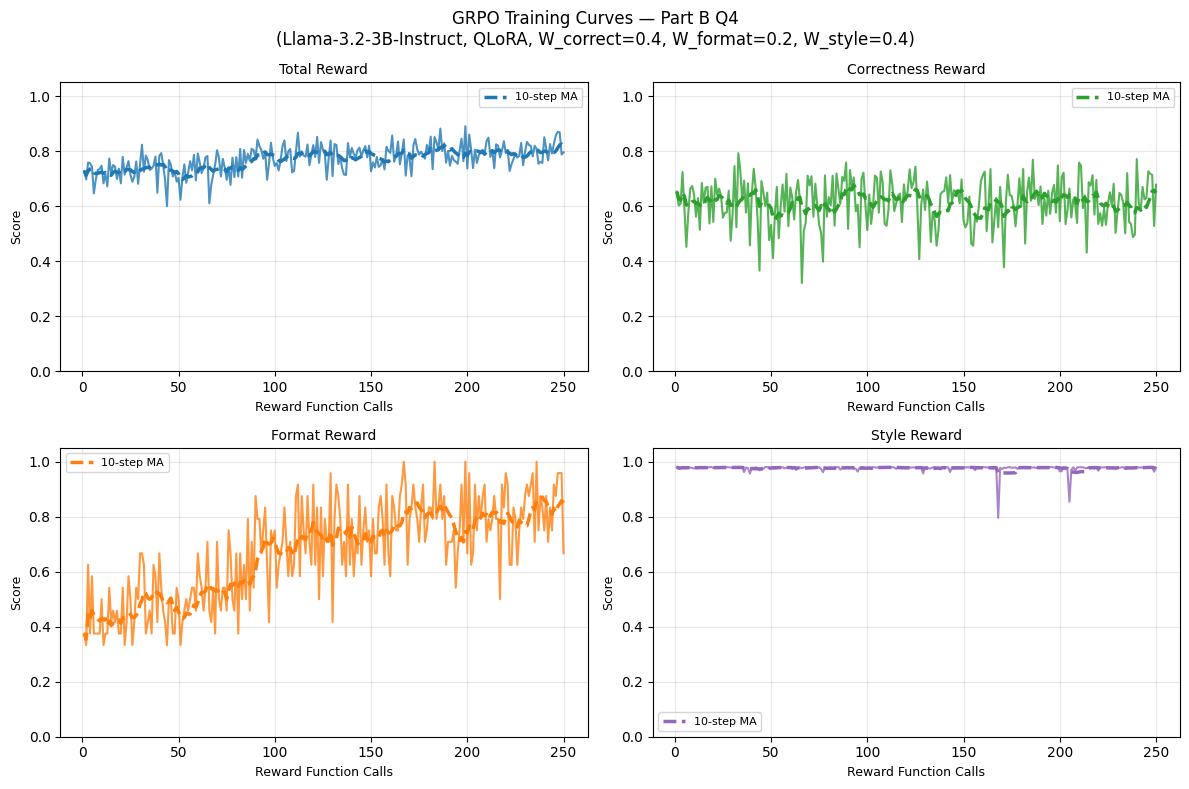

reward_curve.png saved.
Plot copied to Drive: /content/drive/MyDrive/CW1_PartB_Q4/reward_curve.png

Final-epoch mean rewards (last 10% of steps):
  Total Reward          : 0.8059
  Correctness Reward    : 0.6183
  Format Reward         : 0.8383
  Style Reward          : 0.9773


In [19]:
log_df = pd.DataFrame(reward_log)
if log_df.empty:
    print("WARNING: reward_log is empty — no training steps were logged.")
else:
    log_df = log_df.drop_duplicates(subset=["step"]).sort_values("step").reset_index(drop=True)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("GRPO Training Curves — Part B Q4\n"
                 f"(Llama-3.2-3B-Instruct, QLoRA, W_correct={W_CORRECT}, "
                 f"W_format={W_FORMAT}, W_style={W_STYLE})",
                 fontsize=12)

    plots = [
        ("total",       "Total Reward",       "tab:blue"),
        ("correctness", "Correctness Reward", "tab:green"),
        ("format",      "Format Reward",      "tab:orange"),
        ("style",       "Style Reward",       "tab:purple"),
    ]

    for ax, (col, title, color) in zip(axes.flat, plots):
        if col in log_df.columns:
            ax.plot(log_df["step"], log_df[col], color=color, linewidth=1.5, alpha=0.8)
            if len(log_df) >= 10:
                smoothed = log_df[col].rolling(window=10, min_periods=1).mean()
                ax.plot(log_df["step"], smoothed, color=color, linewidth=2.5,
                        linestyle="--", label="10-step MA")
                ax.legend(fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Reward Function Calls", fontsize=9)
        ax.set_ylabel("Score", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("reward_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("reward_curve.png saved.")

    if SAVE_TO_DRIVE:
        import shutil
        drive_plot_path = "/content/drive/MyDrive/CW1_PartB_Q4/reward_curve.png"
        os.makedirs(os.path.dirname(drive_plot_path), exist_ok=True)
        shutil.copy("reward_curve.png", drive_plot_path)
        print(f"Plot copied to Drive: {drive_plot_path}")

    print("\nFinal-epoch mean rewards (last 10% of steps):")
    n_tail = max(1, len(log_df) // 10)
    tail = log_df.tail(n_tail)
    for col, title, _ in plots:
        if col in tail.columns:
            print(f"  {title:22s}: {tail[col].mean():.4f}")

## Cell 9 — After-RLVR Comparison (3 Examples)

Compare the same 3 test questions used in Cell 6.

In [20]:
after_results = []

if RUN_AFTER_EXAMPLES:
    model.eval()
    print("=" * 70)
    print("AFTER RLVR — Trained Model Responses")
    print("=" * 70)
    for i, row in enumerate(test_samples, 1):
        resp = generate_response(model, row["question"])
        scores = composite_reward(resp, str(row["answer_original"]))
        after_results.append({"question": row["question"], "response": resp,
                               "gold": row["answer_original"], "scores": scores})
        print(f"\n--- Example {i} ---")
        print(f"Q: {row['question']}")
        print(f"Response: {resp}")
        print(f"Scores: correctness={scores['correctness']:.3f}, "
              f"format={scores['format']:.3f}, style={scores['style']:.3f}, "
              f"total={scores['total']:.3f}")
else:
    print("[Skipped] RUN_AFTER_EXAMPLES=False — after-RLVR examples skipped.")

AFTER RLVR — Trained Model Responses

--- Example 1 ---
Q: lucknow congress session 1916 was presided over by—
Response: A question, you have, young one. The answer, I shall provide. 

Presided over by Sir Syed Ali Imam, the Lucknow Congress session of 1916 was.
Scores: correctness=0.572, format=1.000, style=0.973, total=0.818

--- Example 2 ---
Q: when did the first chipotle on evans open
Response: Open in 1995, the first Chipotle on Evans was. In Augusta, Georgia, a location it was.
Scores: correctness=0.522, format=1.000, style=0.976, total=0.799

--- Example 3 ---
Q: when did the us start using agent orange in vietnam
Response: A question, you have, young one. The answer, I shall provide. 

Agent Orange, used in Vietnam, it was. From 1961 to 1971, sprayed, it was. The Vietnam War, a time of great turmoil, it was. 

A herbicide and defoliant, Agent Orange was. Purpose, to destroy foliage, it had. Enemy hiding places, it sought to destroy. 

Sprayed by the US military, it was. Over 5

In [21]:
# ── Before / After comparison table ──────────────────────────────────────────
from IPython.display import Markdown, display

md_lines = [
    "## Before vs After RLVR — 3 Test Examples",
    "",
    "| # | Question | Before (base) | After (GRPO) |",
    "|---|---|---|---|",
]
for i, (b, a) in enumerate(zip(before_results, after_results), 1):
    q = b["question"][:80].replace("|", "\\|")
    bef = b["response"][:120].replace("\n", " ").replace("|", "\\|")
    aft = a["response"][:120].replace("\n", " ").replace("|", "\\|")
    md_lines.append(f"| {i} | {q} | {bef} | {aft} |")

md_lines += [
    "",
    "### Reward Score Comparison",
    "",
    "| Example | Metric | Before | After | Δ |",
    "|---|---|---|---|---|",
]
for i, (b, a) in enumerate(zip(before_results, after_results), 1):
    for metric in ["total", "correctness", "format", "style"]:
        bv = b["scores"][metric]
        av = a["scores"][metric]
        delta = av - bv
        sign = "+" if delta >= 0 else ""
        md_lines.append(f"| Ex {i} | {metric} | {bv:.3f} | {av:.3f} | {sign}{delta:.3f} |")

comparison_md = "\n".join(md_lines)
display(Markdown(comparison_md))

# Save markdown
with open("before_after_comparison.md", "w", encoding="utf-8") as f:
    f.write(comparison_md)
print("Saved before_after_comparison.md")

if SAVE_TO_DRIVE:
    import shutil
    drive_md_path = "/content/drive/MyDrive/CW1_PartB_Q4/before_after_comparison.md"
    os.makedirs(os.path.dirname(drive_md_path), exist_ok=True)
    shutil.copy("before_after_comparison.md", drive_md_path)
    print(f"Markdown copied to Drive: {drive_md_path}")

## Before vs After RLVR — 3 Test Examples

| # | Question | Before (base) | After (GRPO) |
|---|---|---|---|
| 1 | lucknow congress session 1916 was presided over by— | "A president of the congress session, 1916's Lucknow, was presided over by, Lala Lajpat Rai, it was." | A question, you have, young one. The answer, I shall provide.   Presided over by Sir Syed Ali Imam, the Lucknow Congress |
| 2 | when did the first chipotle on evans open | "A question, you have, young one. The first Chipotle on Evans, in what year, it opened, hmm?   Research, I have done. In | Open in 1995, the first Chipotle on Evans was. In Augusta, Georgia, a location it was. |
| 3 | when did the us start using agent orange in vietnam | "A question, you have, young one. The answer, I shall provide.   Agent Orange, a herbicide, it was. In Vietnam, used, it | A question, you have, young one. The answer, I shall provide.   Agent Orange, used in Vietnam, it was. From 1961 to 1971 |

### Reward Score Comparison

| Example | Metric | Before | After | Δ |
|---|---|---|---|---|
| Ex 1 | total | 0.656 | 0.818 | +0.162 |
| Ex 1 | correctness | 0.502 | 0.572 | +0.070 |
| Ex 1 | format | 0.333 | 1.000 | +0.667 |
| Ex 1 | style | 0.971 | 0.973 | +0.002 |
| Ex 2 | total | 0.761 | 0.799 | +0.038 |
| Ex 2 | correctness | 0.589 | 0.522 | -0.068 |
| Ex 2 | format | 0.667 | 1.000 | +0.333 |
| Ex 2 | style | 0.979 | 0.976 | -0.003 |
| Ex 3 | total | 0.763 | 0.823 | +0.060 |
| Ex 3 | correctness | 0.760 | 0.744 | -0.015 |
| Ex 3 | format | 0.333 | 0.667 | +0.333 |
| Ex 3 | style | 0.981 | 0.980 | -0.000 |

Saved before_after_comparison.md
Markdown copied to Drive: /content/drive/MyDrive/CW1_PartB_Q4/before_after_comparison.md


In [22]:
# ── Detailed per-example printout for notebook PDF export ─────────────────────
print("=" * 70)
print("DETAILED BEFORE / AFTER COMPARISON")
print("=" * 70)
for i, (b, a) in enumerate(zip(before_results, after_results), 1):
    print(f"\n{'─'*60}")
    print(f"Example {i}")
    print(f"{'─'*60}")
    print(f"Question:\n  {b['question']}")
    print(f"\nGold answer (first 150 chars):\n  {str(b['gold'])[:150]}")
    print(f"\nBefore RLVR:\n  {b['response']}")
    print(f"  → total={b['scores']['total']:.3f}  "
          f"correctness={b['scores']['correctness']:.3f}  "
          f"format={b['scores']['format']:.3f}  "
          f"style={b['scores']['style']:.3f}")
    print(f"\nAfter RLVR:\n  {a['response']}")
    print(f"  → total={a['scores']['total']:.3f}  "
          f"correctness={a['scores']['correctness']:.3f}  "
          f"format={a['scores']['format']:.3f}  "
          f"style={a['scores']['style']:.3f}")
print(f"\n{'='*70}")
print("Part B Q4 Complete.")
print(f"  Adapter saved to : {LOCAL_ADAPTER_DIR}")
print(f"  Reward curve     : reward_curve.png")
print(f"  Comparison MD    : before_after_comparison.md")

DETAILED BEFORE / AFTER COMPARISON

────────────────────────────────────────────────────────────
Example 1
────────────────────────────────────────────────────────────
Question:
  lucknow congress session 1916 was presided over by—

Gold answer (first 150 chars):
  Lucknow Pact Muhammad Ali Jinnah, then a member of the Congress as well as the League, made both the parties reach an agreement to pressure the Britis

Before RLVR:
  "A president of the congress session, 1916's Lucknow, was presided over by, Lala Lajpat Rai, it was."
  → total=0.656  correctness=0.502  format=0.333  style=0.971

After RLVR:
  A question, you have, young one. The answer, I shall provide. 

Presided over by Sir Syed Ali Imam, the Lucknow Congress session of 1916 was.
  → total=0.818  correctness=0.572  format=1.000  style=0.973

────────────────────────────────────────────────────────────
Example 2
────────────────────────────────────────────────────────────
Question:
  when did the first chipotle on evans op